In [1]:
import pandas as pd
import numpy as np
import glob, os

In [2]:
%pip install pandas duckdb

import pandas as pd
import duckdb

Note: you may need to restart the kernel to use updated packages.


In [ ]:
path = r'C:\Users\songj\OneDrive\UNI\Y3SEM1\DATA3888\Project Folder\DATA3888G08\Optiver\individual_book_train'
files = glob.glob(os.path.join(path, "*.csv"))
print(files) 

[]


In [4]:
''' 
These line of code will be commented out since I already merged all file. 
Basically, 126 csv files has been aggregated as week 3's material instruction indicated, the new merged file will contain stock information, WAP, BAS, and
log return.
'''
import duckdb
import os

# ── Config: change this one line to match your machine ──────────────────────
DATA_DIR = '/Users/rosakwak/Desktop/DATA3888/DATA3888G08/individual_book_train'
OUTPUT = '/Users/rosakwak/Desktop/DATA3888/DATA3888G08/optiver_aggregated.csv'
DATA_DIR_DUCK = DATA_DIR.replace('\\', '/')
# ────────────────────────────────────────────────────────────────────────────

conn = duckdb.connect()

result = conn.execute(f"""
    WITH ticks AS (
        SELECT
            stock_id,
            time_id,
            seconds_in_bucket,
            -- WAP per tick
            (bid_price1 * ask_size1 + ask_price1 * bid_size1)
                / (bid_size1 + ask_size1)                          AS wap,
            -- BidAskSpread per tick
            ask_price1 / bid_price1 - 1                            AS bas,
            -- 30-second bucket label (1-indexed)
            CEIL(seconds_in_bucket / 30) + 1                      AS time_bucket
        FROM read_csv_auto('{DATA_DIR_DUCK}/*.csv')
    ),

    returns AS (
        SELECT
            stock_id,
            time_id,
            time_bucket,
            bas,
            LN(wap / LAG(wap) OVER (
                PARTITION BY stock_id, time_id
                ORDER BY seconds_in_bucket
            )) AS log_return
        FROM ticks
    )

    SELECT
        stock_id,
        time_id,
        time_bucket,
        AVG(bas)                                    AS BidAskSpread_mean,
        -- RV = sqrt(sum of squared log returns), skip NULL first-tick return
        SQRT(SUM(log_return * log_return))          AS RV
    FROM returns
    WHERE log_return IS NOT NULL
    GROUP BY stock_id, time_id, time_bucket
    ORDER BY stock_id, time_id, time_bucket

""").df()

result.to_csv(OUTPUT, index=False)
print(result.shape)
print(result.head())

(8569731, 5)
   stock_id  time_id  time_bucket  BidAskSpread_mean        RV
0         0        5          2.0           0.000957  0.001057
1         0        5          3.0           0.000748  0.001266
2         0        5          4.0           0.000876  0.001091
3         0        5          5.0           0.000873  0.000366
4         0        5          6.0           0.000721  0.001339


In [4]:
# size_mb = os.path.getsize(r'C:\Users\songj\OneDrive\UNI\Y3SEM1\DATA3888\Project Folder\optiver_aggregated.csv') / (1024**2)
# print(f"File size: {size_mb:.2f} MB")

# #These code help you check if the current file is overloading your computer, I've saved your laptop :)
# df = pd.read_csv(r'C:\Users\songj\OneDrive\UNI\Y3SEM1\DATA3888\Project Folder\optiver_aggregated.csv')
# mem_mb = df.memory_usage(deep=True).sum() / (1024**2)

# print(f"Shape: {df.shape}")
# print(f"RAM usage: {mem_mb:.2f} MB")
# print(df.head())

In [11]:
%pip install statsmodels scikit-learn matplotlib

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 1.9 MB/s  0:00:05eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 2.0 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 2.3 MB/s  0:00:03 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 2.7 MB/s  0:00:01 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 1.3 MB/s  0:00:04 eta 0:00:010m
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━

Daily data shape: (428932, 5)
   stock_id  time_id  BAS_daily        RV            RQ
0         0        5   0.000852  0.004499  7.406075e-10
1         0       11   0.000393  0.001204  1.000539e-11
2         0       16   0.000725  0.002369  9.679363e-11
3         0       31   0.000863  0.002574  2.084187e-10
4         0       62   0.000396  0.001895  7.160123e-11
Model data shape: (426468, 11)
Train shape: (341128, 11)
Validation shape: (85340, 11)
Train time_id range: 229 to 25713
Validation time_id range: 25716 to 32767

=== HAV-RV / HAR-RV FULL OLS Summary ===
                            OLS Regression Results                            
Dep. Variable:                     RV   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                 1.627e+04
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:54:

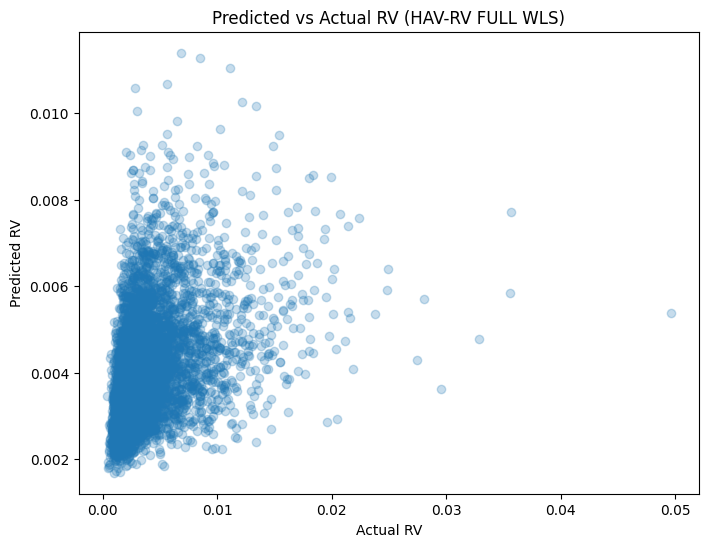

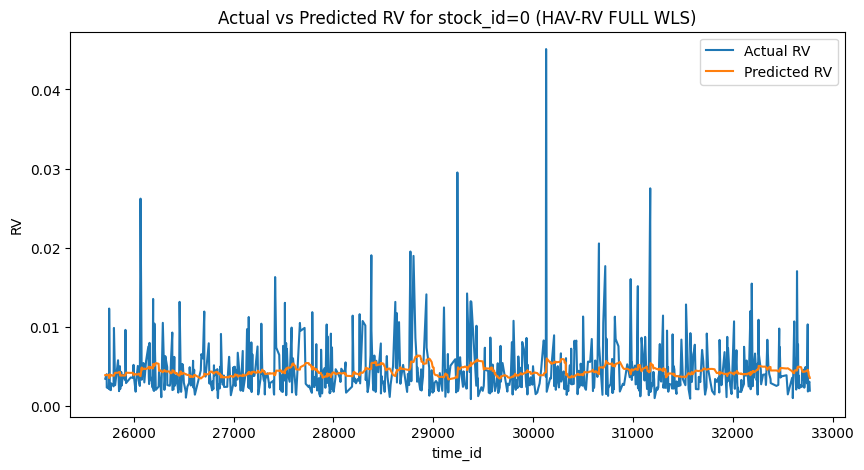

In [ ]:
import duckdb
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error


DATA_DIR = '/Users/rosakwak/Desktop/DATA3888/DATA3888G08/individual_book_train'
DATA_DIR_DUCK = DATA_DIR.replace('\\', '/')

conn = duckdb.connect()

daily = conn.execute(f"""
WITH ticks AS (
    SELECT
        stock_id,
        time_id,
        seconds_in_bucket,
        (bid_price1 * ask_size1 + ask_price1 * bid_size1)
            / NULLIF((bid_size1 + ask_size1), 0) AS wap,
        ask_price1 / NULLIF(bid_price1, 0) - 1 AS bas
    FROM read_csv_auto('{DATA_DIR_DUCK}/*.csv')
),

returns AS (
    SELECT
        stock_id,
        time_id,
        seconds_in_bucket,
        bas,
        LN(wap / LAG(wap) OVER (
            PARTITION BY stock_id, time_id
            ORDER BY seconds_in_bucket
        )) AS log_return
    FROM ticks
),

daily_base AS (
    SELECT
        stock_id,
        time_id,
        AVG(bas) AS BAS_daily,
        SUM(log_return * log_return) AS sum_r2,
        SUM(POWER(log_return, 4)) AS sum_r4,
        COUNT(log_return) AS n_returns
    FROM returns
    WHERE log_return IS NOT NULL
    GROUP BY stock_id, time_id
)

SELECT
    stock_id,
    time_id,
    BAS_daily,
    SQRT(sum_r2) AS RV,
    (n_returns / 3.0) * sum_r4 AS RQ
FROM daily_base
ORDER BY stock_id, time_id
""").df()

print("Daily data shape:", daily.shape)
print(daily.head())

# =========================================================
# 3. CREATE HAV/HAR FEATURES
# =========================================================
daily = daily.sort_values(['stock_id', 'time_id']).reset_index(drop=True)
g = daily.groupby('stock_id')

# Core lagged RV features
daily['RV_lag1'] = g['RV'].shift(1)
daily['RV_week'] = g['RV'].transform(lambda s: s.shift(1).rolling(window=5).mean())
daily['RV_month'] = g['RV'].transform(lambda s: s.shift(1).rolling(window=22).mean())

# RQ lag for WLS weighting
daily['RQ_lag1'] = g['RQ'].shift(1)

# Optional microstructure regressor
daily['BAS_lag1'] = g['BAS_daily'].shift(1)

# Short-series version requested in the table
daily['RV_mean5'] = daily['RV_week']

# Keep only rows with all required variables
df_model = daily.dropna(
    subset=['RV', 'RV_lag1', 'RV_week', 'RV_month', 'RQ_lag1', 'BAS_lag1']
).copy()

print("Model data shape:", df_model.shape)

# =========================================================
# 4. TIME-BASED TRAIN / VALIDATION SPLIT
# =========================================================
unique_time_ids = np.sort(df_model['time_id'].unique())
split_idx = int(len(unique_time_ids) * 0.8)

train_time_ids = unique_time_ids[:split_idx]
valid_time_ids = unique_time_ids[split_idx:]

train = df_model[df_model['time_id'].isin(train_time_ids)].copy()
valid = df_model[df_model['time_id'].isin(valid_time_ids)].copy()

print("Train shape:", train.shape)
print("Validation shape:", valid.shape)
print("Train time_id range:", train['time_id'].min(), "to", train['time_id'].max())
print("Validation time_id range:", valid['time_id'].min(), "to", valid['time_id'].max())

# =========================================================
# 5. EVALUATION FUNCTIONS
# =========================================================
def qlike_loss(y_true, y_pred, eps=1e-12):
    y_true = np.maximum(np.asarray(y_true), eps)
    y_pred = np.maximum(np.asarray(y_pred), eps)
    return np.mean(y_true / y_pred - np.log(y_true / y_pred) - 1)

def evaluate_model(name, y_true, y_pred):
    y_pred = np.maximum(np.asarray(y_pred), 1e-12)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    qlike = qlike_loss(y_true, y_pred)

    print(f"\n{name}")
    print("-" * len(name))
    print(f"MSE   : {mse:.10f}")
    print(f"RMSE  : {rmse:.10f}")
    print(f"MAE   : {mae:.10f}")
    print(f"QLIKE : {qlike:.10f}")

    return {
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'QLIKE': qlike
    }

def beta_ci_table(model, model_name):
    ci = model.conf_int()
    ci.columns = ['CI_lower', 'CI_upper']
    table = pd.DataFrame({
        'coef': model.params,
        'std_err': model.bse,
        't': model.tvalues,
        'p_value': model.pvalues
    }).join(ci)
    table.insert(0, 'Model', model_name)
    return table.reset_index(names='term')

# =========================================================
# 6. DEFINE TARGET
# =========================================================
y_train = train['RV']
y_valid = valid['RV']

# =========================================================
# 7. FULL HAV/HAR MODEL: RV_lag1 + RV_week + RV_month
# =========================================================
X_train_full = train[['RV_lag1', 'RV_week', 'RV_month']]
X_valid_full = valid[['RV_lag1', 'RV_week', 'RV_month']]

X_train_full = sm.add_constant(X_train_full)
X_valid_full = sm.add_constant(X_valid_full)

# OLS
hav_ols = sm.OLS(y_train, X_train_full).fit()
print("\n=== HAV-RV / HAR-RV FULL OLS Summary ===")
print(hav_ols.summary())

valid['pred_hav_ols'] = np.maximum(hav_ols.predict(X_valid_full), 1e-12)
metrics_hav_ols = evaluate_model("HAV-RV FULL OLS", y_valid, valid['pred_hav_ols'])

# WLS with required weight: w_t = RV_{t-1} / sqrt(RQ_{t-1})
weights_train = train['RV_lag1'] / np.sqrt(np.maximum(train['RQ_lag1'], 1e-12))
weights_train = np.maximum(weights_train, 1e-12)

hav_wls = sm.WLS(y_train, X_train_full, weights=weights_train).fit()
print("\n=== HAV-RV / HAR-RV FULL WLS Summary ===")
print(hav_wls.summary())

valid['pred_hav_wls'] = np.maximum(hav_wls.predict(X_valid_full), 1e-12)
metrics_hav_wls = evaluate_model("HAV-RV FULL WLS", y_valid, valid['pred_hav_wls'])

# =========================================================
# 8. SHORT-SERIES MODEL: RV_lag1 + mean_5
#    (requested in the workflow table! for M3 part ;) )
# =========================================================
X_train_short = train[['RV_lag1', 'RV_mean5']]
X_valid_short = valid[['RV_lag1', 'RV_mean5']]

X_train_short = sm.add_constant(X_train_short)
X_valid_short = sm.add_constant(X_valid_short)

# OLS
short_ols = sm.OLS(y_train, X_train_short).fit()
print("\n=== SHORT HAV/HAR OLS Summary (RV_lag1 + mean_5) ===")
print(short_ols.summary())

valid['pred_short_ols'] = np.maximum(short_ols.predict(X_valid_short), 1e-12)
metrics_short_ols = evaluate_model("SHORT HAV/HAR OLS", y_valid, valid['pred_short_ols'])

# WLS
short_wls = sm.WLS(y_train, X_train_short, weights=weights_train).fit()
print("\n=== SHORT HAV/HAR WLS Summary (RV_lag1 + mean_5) ===")
print(short_wls.summary())

valid['pred_short_wls'] = np.maximum(short_wls.predict(X_valid_short), 1e-12)
metrics_short_wls = evaluate_model("SHORT HAV/HAR WLS", y_valid, valid['pred_short_wls'])

# =========================================================
# 9. OPTIONAL EXTENSION: HAR-RV-X / HAV-RV-X WITH BAS
# =========================================================
X_train_x = train[['RV_lag1', 'RV_week', 'RV_month', 'BAS_lag1']]
X_valid_x = valid[['RV_lag1', 'RV_week', 'RV_month', 'BAS_lag1']]

X_train_x = sm.add_constant(X_train_x)
X_valid_x = sm.add_constant(X_valid_x)

havx_ols = sm.OLS(y_train, X_train_x).fit()
print("\n=== HAV-RV-X OLS Summary ===")
print(havx_ols.summary())

valid['pred_havx_ols'] = np.maximum(havx_ols.predict(X_valid_x), 1e-12)
metrics_havx_ols = evaluate_model("HAV-RV-X OLS", y_valid, valid['pred_havx_ols'])

# =========================================================
# 10. MODEL COMPARISON TABLE
# =========================================================
comparison = pd.DataFrame([
    metrics_hav_ols,
    metrics_hav_wls,
    metrics_short_ols,
    metrics_short_wls,
    metrics_havx_ols
]).sort_values('QLIKE')

print("\n=== Model Comparison ===")
print(comparison)

# =========================================================
# 11. BETA ESTIMATES + 95% CIs
# =========================================================
beta_tables = pd.concat([
    beta_ci_table(hav_ols, "HAV-RV FULL OLS"),
    beta_ci_table(hav_wls, "HAV-RV FULL WLS"),
    beta_ci_table(short_ols, "SHORT HAV/HAR OLS"),
    beta_ci_table(short_wls, "SHORT HAV/HAR WLS"),
    beta_ci_table(havx_ols, "HAV-RV-X OLS")
], ignore_index=True)

print("\n=== Beta Estimates + 95% CIs ===")
print(beta_tables)

# =========================================================
# 12. BEST MODEL BY QLIKE
# =========================================================
best_model_name = comparison.iloc[0]['Model']
print("\nBest model by QLIKE:", best_model_name)

pred_map = {
    'HAV-RV FULL OLS': 'pred_hav_ols',
    'HAV-RV FULL WLS': 'pred_hav_wls',
    'SHORT HAV/HAR OLS': 'pred_short_ols',
    'SHORT HAV/HAR WLS': 'pred_short_wls',
    'HAV-RV-X OLS': 'pred_havx_ols'
}

pred_col = pred_map[best_model_name]

# =========================================================
# 13. PREDICTED VS ACTUAL RV PLOT
# =========================================================
sample_plot = valid[['RV', pred_col]].sample(
    n=min(5000, len(valid)),
    random_state=42
)

plt.figure(figsize=(8, 6))
plt.scatter(sample_plot['RV'], sample_plot[pred_col], alpha=0.25)
plt.xlabel('Actual RV')
plt.ylabel('Predicted RV')
plt.title(f'Predicted vs Actual RV ({best_model_name})')
plt.show()

# =========================================================
# 14. TIME-SERIES PLOT FOR ONE STOCK
# =========================================================
example_stock = valid['stock_id'].iloc[0]
stock_plot = valid[valid['stock_id'] == example_stock].sort_values('time_id')

plt.figure(figsize=(10, 5))
plt.plot(stock_plot['time_id'], stock_plot['RV'], label='Actual RV')
plt.plot(stock_plot['time_id'], stock_plot[pred_col], label='Predicted RV')
plt.xlabel('time_id')
plt.ylabel('RV')
plt.title(f'Actual vs Predicted RV for stock_id={example_stock} ({best_model_name})')
plt.legend()
plt.show() 